# Problem 6.2 — Few-Shot Learning with Prototypical Networks

## 1. Theoretical Background

### 1.1 What is Few-Shot Learning?

Classical supervised learning requires hundreds or thousands of labeled examples per class.
**Few-shot learning** (FSL) relaxes this requirement and studies how a model can generalize
from only a handful of labeled examples — mirroring the way humans effortlessly learn new
concepts from a single demonstration.

### 1.2 N-way K-shot Formulation

Each **episode** (task) is a small classification problem drawn from a large pool of classes:

* **Support set** $\mathcal{S}$: $N$ classes $\times$ $K$ labeled images each → $N \cdot K$ total samples  
* **Query set** $\mathcal{Q}$: $N$ classes $\times$ $Q$ images to classify using only $\mathcal{S}$

We evaluate two standard benchmarks: **5-way 1-shot** ($N=5, K=1$) and **5-way 5-shot** ($N=5, K=5$).

### 1.3 Prototypical Networks

Prototypical Networks (Snell et al., 2017) learn an embedding function
$f_\phi : \mathbb{R}^D \rightarrow \mathbb{R}^M$ that maps images into a metric space
where same-class samples cluster together.

**Step 1 — Compute class prototypes** as the mean of support-set embeddings:

$$\mathbf{c}_n = \frac{1}{K} \sum_{(\mathbf{x}_i,\, y_i)\,\in\,\mathcal{S}_n} f_\phi(\mathbf{x}_i)$$
 where $\mathcal{S}_n$ is support set for $n$-th class.

**Step 2 — Classify each query** by the nearest prototype (softmax over negative squared Euclidean distances):

$$p(y = n \mid \mathbf{x}) = \frac{\exp\!\left(-d\left(f_\phi(\mathbf{x}),\, \mathbf{c}_n\right)\right)}{\sum_{n'} \exp\!\left(-d\left(f_\phi(\mathbf{x}),\, \mathbf{c}_{n'}\right)\right)}, \quad d(\mathbf{a},\mathbf{b}) = \|\mathbf{a}-\mathbf{b}\|_2^2$$

**Step 3 — Optimise the cross-entropy loss** on query predictions across many episodes.

> **Key insight:** the prototype is the class *centroid* in embedding space.
> The network is trained end-to-end to make these centroids maximally discriminative.

In [1]:
# ── Core imports ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

import torchvision
import torchvision.transforms as transforms

import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device        : {DEVICE}')
print(f'PyTorch       : {torch.__version__}')
print(f'Torchvision   : {torchvision.__version__}')

# ── Global hyper-parameters ───────────────────────────────────────────────────
N_WAY          = 5    # number of classes per episode
K_SHOT_TRAIN   = 5    # support shots used during training
N_QUERY        = 10   # query images per class per episode
N_EPOCHS       = 10   # training epochs
N_TRAIN_EPS    = 100  # training episodes per epoch
N_TEST_EPS     = 200  # evaluation episodes
LR             = 1e-3 # initial learning rate

Device        : cuda
PyTorch       : 2.6.0+cu124
Torchvision   : 0.21.0+cu124


## 2. The Omniglot Dataset

**Omniglot** (Lake et al., 2011) is the standard benchmark for few-shot image classification.
It contains **1 623 handwritten character classes** from 50 different world alphabets,
with exactly **20 images per class** (drawn by different participants).

The dataset is pre-divided into two non-overlapping splits:

| Split | Classes | Total images | Used for |
|---|---|---|---|
| **Background** | 964 | 19 280 | Meta-training (finding $\phi$) |
| **Evaluation** | 659 | 13 180 | Meta-testing (unseen classes) |

**Preprocessing:** images are resized to $28 \times 28$ and **inverted** so that
characters appear as white strokes on a black background (standard convention).
A final $\mathcal{N}(0.5, 0.5)$ normalisation centres the pixel distribution.

In [2]:
# ── Image pipeline ────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x),      # invert: white strokes on black
    transforms.Normalize((0.5,), (0.5,))        # map [0,1] -> [-1, 1]
])

# ── Load splits ───────────────────────────────────────────────────────────────
print('Downloading / loading Omniglot background set (train)...')
train_dataset = torchvision.datasets.Omniglot(
    root='./data', background=True, transform=transform, download=True
)

print('Downloading / loading Omniglot evaluation set (test)...')
test_dataset = torchvision.datasets.Omniglot(
    root='./data', background=False, transform=transform, download=True
)

# Count unique classes per split
n_train_classes = len(set(lbl for _, lbl in train_dataset._flat_character_images))
n_test_classes  = len(set(lbl for _, lbl in test_dataset._flat_character_images))

print(f'\nTraining set   : {len(train_dataset):6d} images | {n_train_classes} classes')
print(f'Test set       : {len(test_dataset):6d} images | {n_test_classes} classes')

100%|██████████| 9.46M/9.46M [00:00<00:00, 37.7MB/s]


100%|██████████| 6.46M/6.46M [00:00<00:00, 36.1MB/s]



Training set   :  19280 images | 964 classes
Test set       :  13180 images | 659 classes


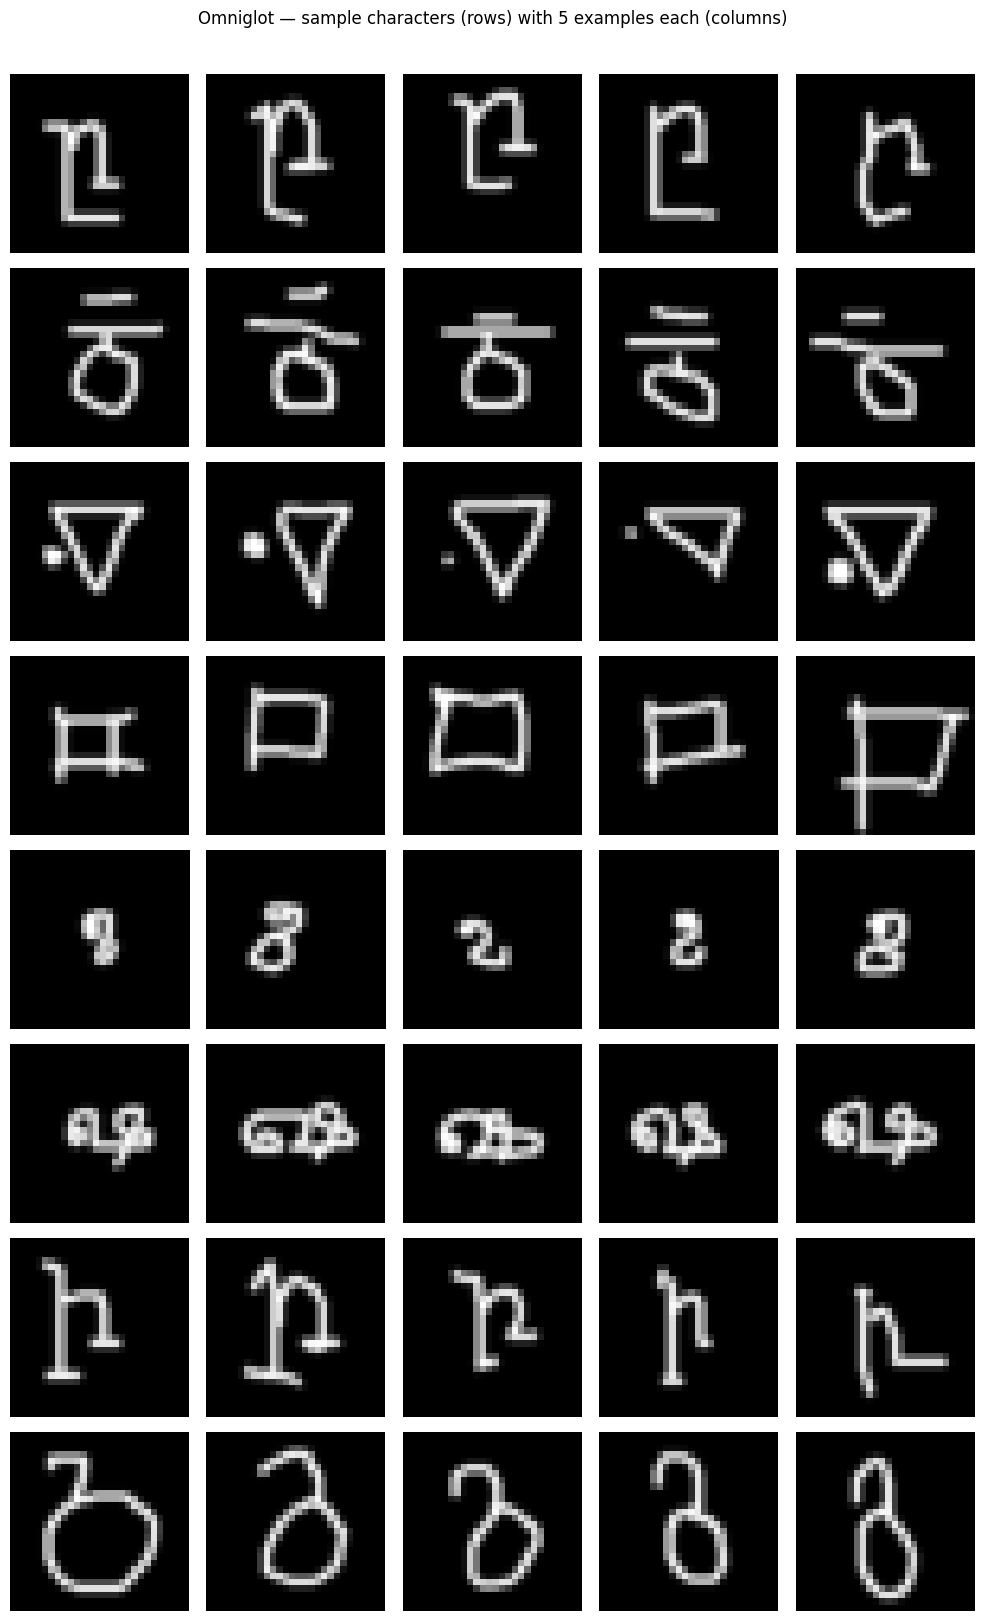

In [3]:
# ── Visualise a few training characters ──────────────────────────────────────
# Pick 8 random classes and display 5 images each
rng = np.random.default_rng(SEED)
class_to_train_idx = defaultdict(list)
for idx, (_, lbl) in enumerate(train_dataset._flat_character_images):
    class_to_train_idx[lbl].append(idx)

sample_classes = rng.choice(list(class_to_train_idx.keys()), size=8, replace=False)

fig, axes = plt.subplots(8, 5, figsize=(10, 16))
fig.suptitle('Omniglot — sample characters (rows) with 5 examples each (columns)',
             fontsize=12, y=1.01)

for row, cls in enumerate(sample_classes):
    indices = class_to_train_idx[cls][:5]
    for col, idx in enumerate(indices):
        img, _ = train_dataset[idx]
        axes[row, col].imshow(img.squeeze(), cmap='gray', vmin=-1, vmax=1)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 3. Episodic Learning Framework

### Why Episodic Training?

Standard mini-batch training does not directly optimise the few-shot objective.
**Episodic training** instead samples many small tasks (episodes) that mimic
the test-time scenario. At each step:

1. Sample $N$ classes uniformly at random from the training split.
2. Sample $K$ **support** images and $Q$ **query** images from each class.
3. Forward-pass all $N(K+Q)$ images through the embedding network.
4. Compute prototypes $\{\mathbf{c}_k\}$ from support embeddings.
5. Compute the prototypical loss on query predictions.
6. Back-propagate and update $\phi$.

This trains the network to quickly adapt to new classes with very few examples,
because it sees a new "task" at every step.

In [4]:
class EpisodeSampler:
    """
    Constructs N-way K-shot episodes from an Omniglot split.

    The class-to-indices mapping is built once from dataset metadata
    (no image loading required for the index), keeping initialisation fast.
    """

    def __init__(self, dataset, n_way: int, k_shot: int, n_query: int):
        self.dataset = dataset
        self.n_way   = n_way
        self.k_shot  = k_shot
        self.n_query = n_query

        # Build class -> list-of-dataset-indices mapping without loading images
        self.class_to_indices: dict = defaultdict(list)
        for idx, (_, lbl) in enumerate(dataset._flat_character_images):
            self.class_to_indices[lbl].append(idx)

        # Keep only classes that have enough samples for one episode
        min_samples = k_shot + n_query
        self.valid_classes = [
            c for c, idxs in self.class_to_indices.items()
            if len(idxs) >= min_samples
        ]

        print(
            f'EpisodeSampler | {len(self.valid_classes)} valid classes '
            f'| {n_way}-way {k_shot}-shot | {n_query} queries/class'
        )

    def sample_episode(self):
        """
        Returns a tuple of four tensors:
            support_images  : (N*K, 1, H, W)
            support_labels  : (N*K,)          [0 .. N-1, local to episode]
            query_images    : (N*Q, 1, H, W)
            query_labels    : (N*Q,)
        """
        episode_classes = random.sample(self.valid_classes, self.n_way)

        sup_imgs, sup_lbls = [], []
        qry_imgs, qry_lbls = [], []

        for local_lbl, cls in enumerate(episode_classes):
            selected = random.sample(
                self.class_to_indices[cls],
                self.k_shot + self.n_query
            )
            for i, idx in enumerate(selected):
                img, _ = self.dataset[idx]
                if i < self.k_shot:
                    sup_imgs.append(img)
                    sup_lbls.append(local_lbl)
                else:
                    qry_imgs.append(img)
                    qry_lbls.append(local_lbl)

        return (
            torch.stack(sup_imgs),
            torch.tensor(sup_lbls),
            torch.stack(qry_imgs),
            torch.tensor(qry_lbls)
        )


# Instantiate samplers (used later; also serves as a sanity check)
train_sampler = EpisodeSampler(
    train_dataset, n_way=N_WAY, k_shot=K_SHOT_TRAIN, n_query=N_QUERY
)

EpisodeSampler | 964 valid classes | 5-way 5-shot | 10 queries/class


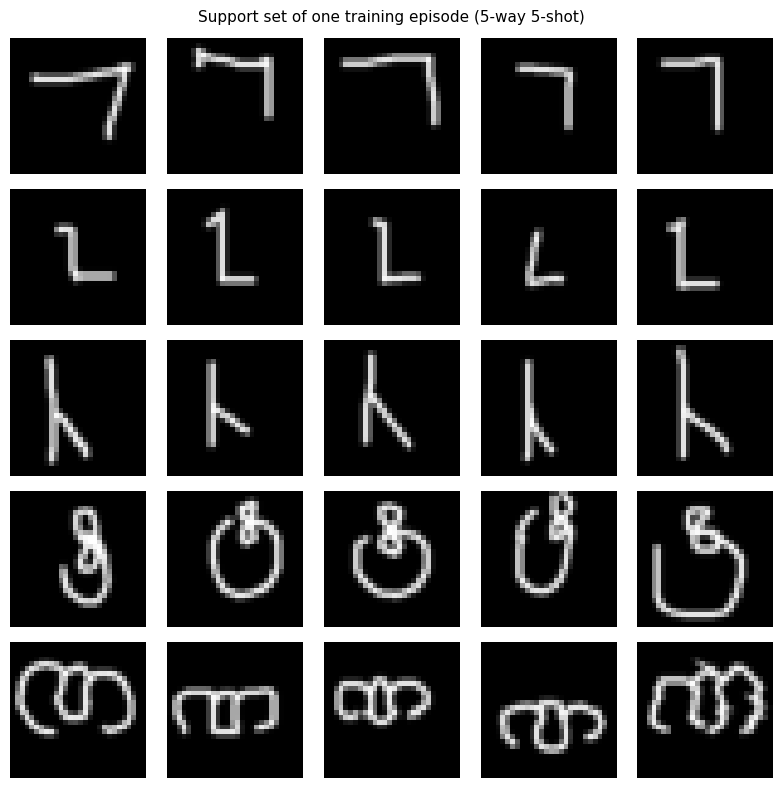

Support tensor shape : torch.Size([25, 1, 28, 28])
Query   tensor shape : torch.Size([50, 1, 28, 28])


In [5]:
# ── Visualise one training episode ───────────────────────────────────────────
# Sample one episode and display the support set (5 classes × 5 shots)
sup_imgs, sup_lbls, qry_imgs, qry_lbls = train_sampler.sample_episode()

fig, axes = plt.subplots(N_WAY, K_SHOT_TRAIN, figsize=(K_SHOT_TRAIN * 1.6, N_WAY * 1.6))
fig.suptitle(
    f'Support set of one training episode ({N_WAY}-way {K_SHOT_TRAIN}-shot)',
    fontsize=11
)

for c in range(N_WAY):
    class_mask = (sup_lbls == c).nonzero(as_tuple=True)[0]
    for k, idx in enumerate(class_mask):
        axes[c, k].imshow(sup_imgs[idx].squeeze(), cmap='gray', vmin=-1, vmax=1)
        axes[c, k].axis('off')
    axes[c, 0].set_ylabel(f'Class {c}', fontsize=9, rotation=0,
                          labelpad=40, va='center')

plt.tight_layout()
plt.show()
print(f'Support tensor shape : {sup_imgs.shape}')
print(f'Query   tensor shape : {qry_imgs.shape}')

## 4. Embedding Network Architecture

The embedding function $f_\phi$ is a **four-block convolutional network**, the standard
architecture used for Omniglot in the original ProtoNets paper.

Each block applies:
$$\text{Conv}(3\times3, \text{pad}=1) \;\rightarrow\; \text{BatchNorm} \;\rightarrow\; \text{ReLU} \;\rightarrow\; \text{MaxPool}(2)$$

Spatial resolution for a $28\times28$ input:

| Block | Output size |
|---|---|
| Input | $1 \times 28 \times 28$ |
| Block 1 | $64 \times 14 \times 14$ |
| Block 2 | $64 \times 7 \times 7$ |
| Block 3 | $64 \times 3 \times 3$ |
| Block 4 + Flatten | $\mathbf{64}$-dim vector |

The final **64-dimensional** embedding vector is used to compute prototypes and distances.
BatchNorm accelerates convergence; MaxPool provides spatial downsampling and slight
translation invariance.

In [6]:
class ConvBlock(nn.Module):
    """Conv 3x3 -> BatchNorm -> ReLU -> MaxPool(2)."""

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class EmbeddingNet(nn.Module):
    """
    4-layer CNN encoder for 28x28 grayscale Omniglot images.
    Produces a 64-dimensional L2-normalised embedding vector.
    """

    def __init__(self, embed_dim: int = 64):
        super().__init__()
        self.embed_dim = embed_dim
        self.encoder = nn.Sequential(
            ConvBlock(1,  64),   # 28x28 -> 14x14
            ConvBlock(64, 64),   # 14x14 ->  7x7
            ConvBlock(64, 64),   #  7x7  ->  3x3
            ConvBlock(64, 64),   #  3x3  ->  1x1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 1, 28, 28)
        out = self.encoder(x)               # (B, 64, 1, 1)
        out = out.view(out.size(0), -1)     # (B, 64)
        return out


# ── Quick shape check ─────────────────────────────────────────────────────────
dummy = torch.zeros(4, 1, 28, 28)
net   = EmbeddingNet()
out   = net(dummy)
print(f'Input  shape : {list(dummy.shape)}')
print(f'Output shape : {list(out.shape)}  (should be [4, 64])')

n_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Input  shape : [4, 1, 28, 28]
Output shape : [4, 64]  (should be [4, 64])
Trainable parameters: 111,680


## 5. Training with Episodic Learning

### Loss Function

For one episode the prototypical loss is the average negative log-probability
of the correct class over all query images:

$$\mathcal{L} = -\frac{1}{N \cdot Q} \sum_{(\mathbf{x}_j,\, y_j)\in\mathcal{Q}}
  \log\, p(y_j \mid \mathbf{x}_j)$$

### Optimisation Strategy

| Setting | Value |
|---|---|
| Optimiser | Adam, $\beta_1=0.9$, $\beta_2=0.999$ |
| Initial LR | $10^{-3}$ |
| LR schedule | StepLR: halve every 3 epochs |
| Training episodes | $10\text{ epochs} \times 100\text{ eps/epoch} = 1\,000$ |
| Training config | 5-way, 5-shot support, 10 queries/class |

In [7]:
# ── Utility: pairwise squared Euclidean distance ──────────────────────────────
def euclidean_dist(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Pairwise squared Euclidean distance matrix.

    Args:
        x : (n, d)
        y : (m, d)
    Returns:
        dist : (n, m)  where dist[i,j] = ||x[i] - y[j]||^2
    """
    n, d = x.size()
    m    = y.size(0)
    x_e  = x.unsqueeze(1).expand(n, m, d)   # (n, m, d)
    y_e  = y.unsqueeze(0).expand(n, m, d)   # (n, m, d)
    return (x_e - y_e).pow(2).sum(2)         # (n, m)


# ── Core: prototypical loss ───────────────────────────────────────────────────
def prototypical_loss(
    sup_emb:  torch.Tensor,   # (N*K, D)
    sup_lbls: torch.Tensor,   # (N*K,)
    qry_emb:  torch.Tensor,   # (N*Q, D)
    qry_lbls: torch.Tensor,   # (N*Q,)
    n_way:    int
):
    """
    Compute the prototypical network loss and episode accuracy.

    Returns:
        loss : scalar tensor (cross-entropy over queries)
        acc  : float in [0, 1]
    """
    # 1. Prototypes: mean embedding per class
    prototypes = torch.stack(
        [sup_emb[sup_lbls == c].mean(0) for c in range(n_way)]
    )  # (N, D)

    # 2. Squared Euclidean distances from queries to prototypes
    dists = euclidean_dist(qry_emb, prototypes)  # (N*Q, N)

    # 3. Log-probabilities via softmax over negative distances
    log_probs = F.log_softmax(-dists, dim=1)     # (N*Q, N)

    # 4. NLL loss == cross-entropy on log-softmax outputs
    loss = F.nll_loss(log_probs, qry_lbls)

    # 5. Episode accuracy
    preds = log_probs.argmax(dim=1)
    acc   = (preds == qry_lbls).float().mean().item()

    return loss, acc


# ── Helper: one forward pass through a single episode ─────────────────────────
def run_episode(
    model:     nn.Module,
    sampler:   EpisodeSampler,
    device:    torch.device,
    optimizer: optim.Optimizer = None
):
    """
    Sample and process one episode.
    If optimizer is provided, performs a gradient update (training mode).
    Otherwise runs in evaluation mode without gradients.
    """
    training = optimizer is not None
    model.train(training)

    sup_img, sup_lbl, qry_img, qry_lbl = sampler.sample_episode()
    sup_img = sup_img.to(device)
    sup_lbl = sup_lbl.to(device)
    qry_img = qry_img.to(device)
    qry_lbl = qry_lbl.to(device)

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        # Encode support + query in one batch for efficiency
        all_emb = model(torch.cat([sup_img, qry_img], dim=0))
        n_sup   = sup_img.size(0)
        loss, acc = prototypical_loss(
            all_emb[:n_sup], sup_lbl,
            all_emb[n_sup:], qry_lbl,
            sampler.n_way
        )
        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return loss.item(), acc

In [8]:
# ── Training loop ─────────────────────────────────────────────────────────────
def train_model(model, sampler, device, n_epochs, n_eps_per_epoch, lr):
    """
    Train the embedding network episodically.

    Returns a history dict with per-epoch loss and accuracy.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=3, gamma=0.5)
    history   = {'loss': [], 'acc': []}

    for epoch in range(1, n_epochs + 1):
        ep_losses, ep_accs = [], []

        for _ in range(n_eps_per_epoch):
            loss, acc = run_episode(model, sampler, device, optimizer=optimizer)
            ep_losses.append(loss)
            ep_accs.append(acc)

        scheduler.step()
        mean_loss = float(np.mean(ep_losses))
        mean_acc  = float(np.mean(ep_accs))
        history['loss'].append(mean_loss)
        history['acc'].append(mean_acc)

        print(
            f'Epoch {epoch:2d}/{n_epochs}  |  '
            f'Loss: {mean_loss:.4f}  |  '
            f'Train Acc: {mean_acc:.4f}  |  '
            f'LR: {scheduler.get_last_lr()[0]:.2e}'
        )

    return history


# ── Initialise model and train ────────────────────────────────────────────────
model = EmbeddingNet(embed_dim=64).to(DEVICE)

print('Training Prototypical Network (5-way 5-shot, episodic)...')
print('=' * 60)
history = train_model(
    model, train_sampler, DEVICE,
    n_epochs=N_EPOCHS,
    n_eps_per_epoch=N_TRAIN_EPS,
    lr=LR
)
print('=' * 60)
print('Training complete.')

Training Prototypical Network (5-way 5-shot, episodic)...
Epoch  1/10  |  Loss: 0.3650  |  Train Acc: 0.9054  |  LR: 1.00e-03
Epoch  2/10  |  Loss: 0.1529  |  Train Acc: 0.9514  |  LR: 1.00e-03
Epoch  3/10  |  Loss: 0.0780  |  Train Acc: 0.9736  |  LR: 5.00e-04
Epoch  4/10  |  Loss: 0.0504  |  Train Acc: 0.9844  |  LR: 5.00e-04
Epoch  5/10  |  Loss: 0.0564  |  Train Acc: 0.9808  |  LR: 5.00e-04
Epoch  6/10  |  Loss: 0.0516  |  Train Acc: 0.9826  |  LR: 2.50e-04
Epoch  7/10  |  Loss: 0.0487  |  Train Acc: 0.9824  |  LR: 2.50e-04
Epoch  8/10  |  Loss: 0.0366  |  Train Acc: 0.9870  |  LR: 2.50e-04
Epoch  9/10  |  Loss: 0.0410  |  Train Acc: 0.9854  |  LR: 1.25e-04
Epoch 10/10  |  Loss: 0.0313  |  Train Acc: 0.9886  |  LR: 1.25e-04
Training complete.


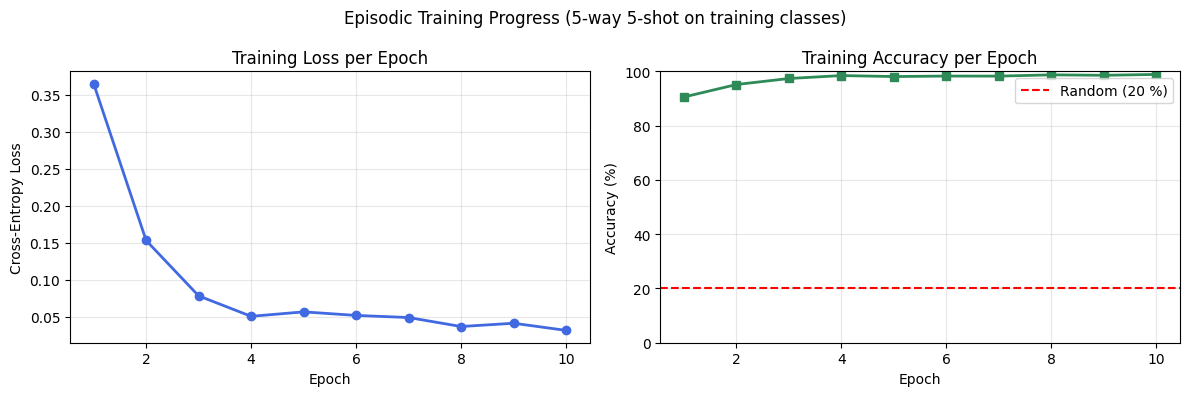

Final train acc: 98.86 %  (random baseline: 20.0 %)


In [9]:
# ── Plot training curves ──────────────────────────────────────────────────────
epochs = range(1, N_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['loss'], 'o-', color='royalblue', lw=2, ms=6)
ax1.set_title('Training Loss per Epoch', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(alpha=0.3)

ax2.plot(epochs, [a * 100 for a in history['acc']], 's-', color='seagreen', lw=2, ms=6)
ax2.axhline(100 / N_WAY, color='red', ls='--', lw=1.5, label=f'Random ({100 / N_WAY:.0f} %)')
ax2.set_title('Training Accuracy per Epoch', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Episodic Training Progress (5-way 5-shot on training classes)', fontsize=12)
plt.tight_layout()
plt.show()

print(
    f'Final train acc: {history["acc"][-1]*100:.2f} %  '
    f'(random baseline: {100/N_WAY:.1f} %)'
)

## 6. Evaluation on Unseen Classes

The critical property of few-shot learning is **generalisation to new classes** that were
never seen during training.  We therefore evaluate on the held-out **evaluation split** of
Omniglot (659 classes disjoint from the 964 training classes).

We measure performance under two standard benchmarks:

| Setting | Support per class | Total support | Expected difficulty |
|---|---|---|---|
| **5-way 1-shot** | 1 | 5 | Hard — each prototype is a single image |
| **5-way 5-shot** | 5 | 25 | Easier — prototype averages over 5 images |

We report **mean accuracy ± 95 % confidence interval** over 200 test episodes.

In [10]:
def evaluate_model(model, sampler, device, n_episodes):
    """
    Evaluate the model over n_episodes and report mean accuracy ± 95% CI.

    Returns:
        mean_acc : float
        ci95     : float  (half-width of 95 % confidence interval)
        accs     : list[float]  (per-episode accuracies)
    """
    model.eval()
    accs = []
    for _ in range(n_episodes):
        _, acc = run_episode(model, sampler, device, optimizer=None)
        accs.append(acc)
    mean_acc = float(np.mean(accs))
    ci95     = 1.96 * float(np.std(accs)) / np.sqrt(n_episodes)
    return mean_acc, ci95, accs


# ── 5-way 1-shot ──────────────────────────────────────────────────────────────
print('Evaluating 5-way 1-shot...')
sampler_1shot = EpisodeSampler(
    test_dataset, n_way=5, k_shot=1, n_query=N_QUERY
)
mean_1shot, ci95_1shot, accs_1shot = evaluate_model(
    model, sampler_1shot, DEVICE, N_TEST_EPS
)
print(f'  5-way 1-shot accuracy: {mean_1shot*100:.2f} % ± {ci95_1shot*100:.2f} %')

# ── 5-way 5-shot ──────────────────────────────────────────────────────────────
print('Evaluating 5-way 5-shot...')
sampler_5shot = EpisodeSampler(
    test_dataset, n_way=5, k_shot=5, n_query=N_QUERY
)
mean_5shot, ci95_5shot, accs_5shot = evaluate_model(
    model, sampler_5shot, DEVICE, N_TEST_EPS
)
print(f'  5-way 5-shot accuracy: {mean_5shot*100:.2f} % ± {ci95_5shot*100:.2f} %')

Evaluating 5-way 1-shot...
EpisodeSampler | 659 valid classes | 5-way 1-shot | 10 queries/class
  5-way 1-shot accuracy: 90.54 % ± 1.14 %
Evaluating 5-way 5-shot...
EpisodeSampler | 659 valid classes | 5-way 5-shot | 10 queries/class
  5-way 5-shot accuracy: 97.82 % ± 0.35 %


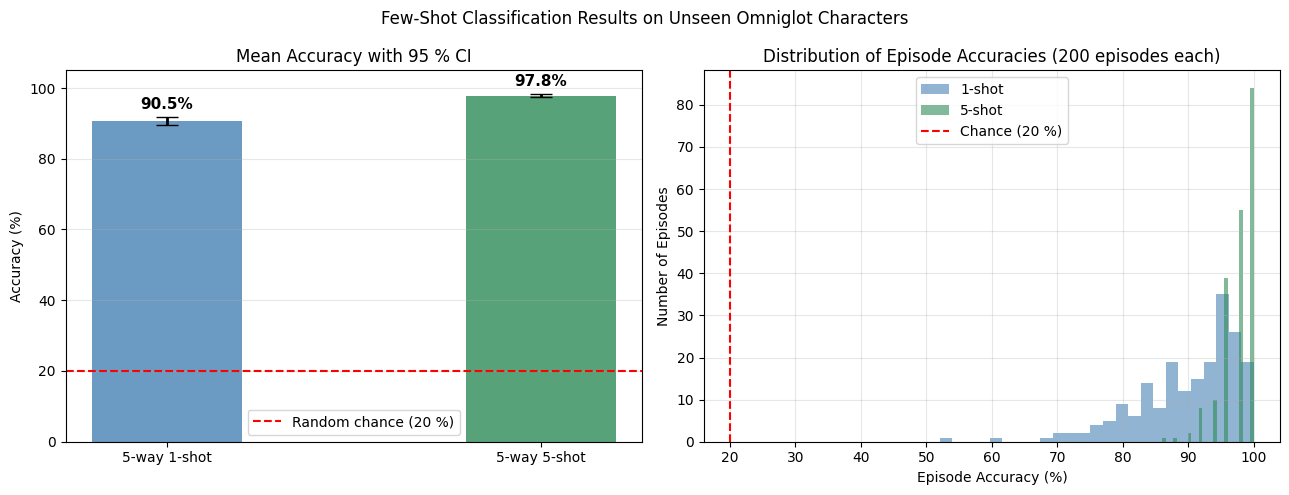


 Result Summary
  Setting       | Mean Acc | 95% CI
  5-way 1-shot  |  90.54 %  | ± 1.14 %
  5-way 5-shot  |  97.82 %  | ± 0.35 %
  Random chance |  20.00 %  |


In [11]:
# ── Visualise: bar chart + per-episode distribution ───────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Bar chart with CI error bars ---
labels  = ['5-way 1-shot', '5-way 5-shot']
means   = [mean_1shot * 100, mean_5shot * 100]
cis     = [ci95_1shot * 100, ci95_5shot * 100]
colors  = ['steelblue', 'seagreen']
random_baseline = 100.0 / N_WAY

bars = ax1.bar(labels, means, color=colors, alpha=0.8, width=0.4,
               yerr=cis, capsize=8, error_kw={'lw': 2})
ax1.axhline(random_baseline, color='red', ls='--', lw=1.5,
            label=f'Random chance ({random_baseline:.0f} %)')

for bar, mean, ci in zip(bars, means, cis):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             mean + ci + 1.5,
             f'{mean:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylim(0, 105)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Mean Accuracy with 95 % CI', fontsize=12)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# --- Episode accuracy histograms ---
ax2.hist([a * 100 for a in accs_1shot], bins=25, alpha=0.6,
         color='steelblue', label='1-shot')
ax2.hist([a * 100 for a in accs_5shot], bins=25, alpha=0.6,
         color='seagreen', label='5-shot')
ax2.axvline(random_baseline, color='red', ls='--', lw=1.5,
            label=f'Chance ({random_baseline:.0f} %)')
ax2.set_xlabel('Episode Accuracy (%)')
ax2.set_ylabel('Number of Episodes')
ax2.set_title(f'Distribution of Episode Accuracies ({N_TEST_EPS} episodes each)',
              fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Few-Shot Classification Results on Unseen Omniglot Characters',
             fontsize=12)
plt.tight_layout()
plt.show()

# Summary table
print('\n Result Summary')
print('=' * 46)
print(f'  Setting       | Mean Acc | 95% CI')
print(f'  5-way 1-shot  | {mean_1shot*100:6.2f} %  | ± {ci95_1shot*100:.2f} %')
print(f'  5-way 5-shot  | {mean_5shot*100:6.2f} %  | ± {ci95_5shot*100:.2f} %')
print(f'  Random chance | {random_baseline:6.2f} %  |')
print('=' * 46)

## 7. t-SNE Visualisation of the Embedding Space

To gain intuition about *why* Prototypical Networks work, we use
**t-SNE** to project the 64-dimensional
embedding vectors down to 2D.

We embed all 20 images from each of **12 randomly selected test classes**
(characters never seen during training) and colour each point by its class.
A well-trained model should produce **tight clusters** for each class,
separated from the other clusters — exactly the geometry that makes nearest-prototype
classification accurate.

We also overlay the class **prototype** (centroid of each cluster) as a larger marker
to show what the network uses for classification.

Running t-SNE on 252 vectors (12 classes)...


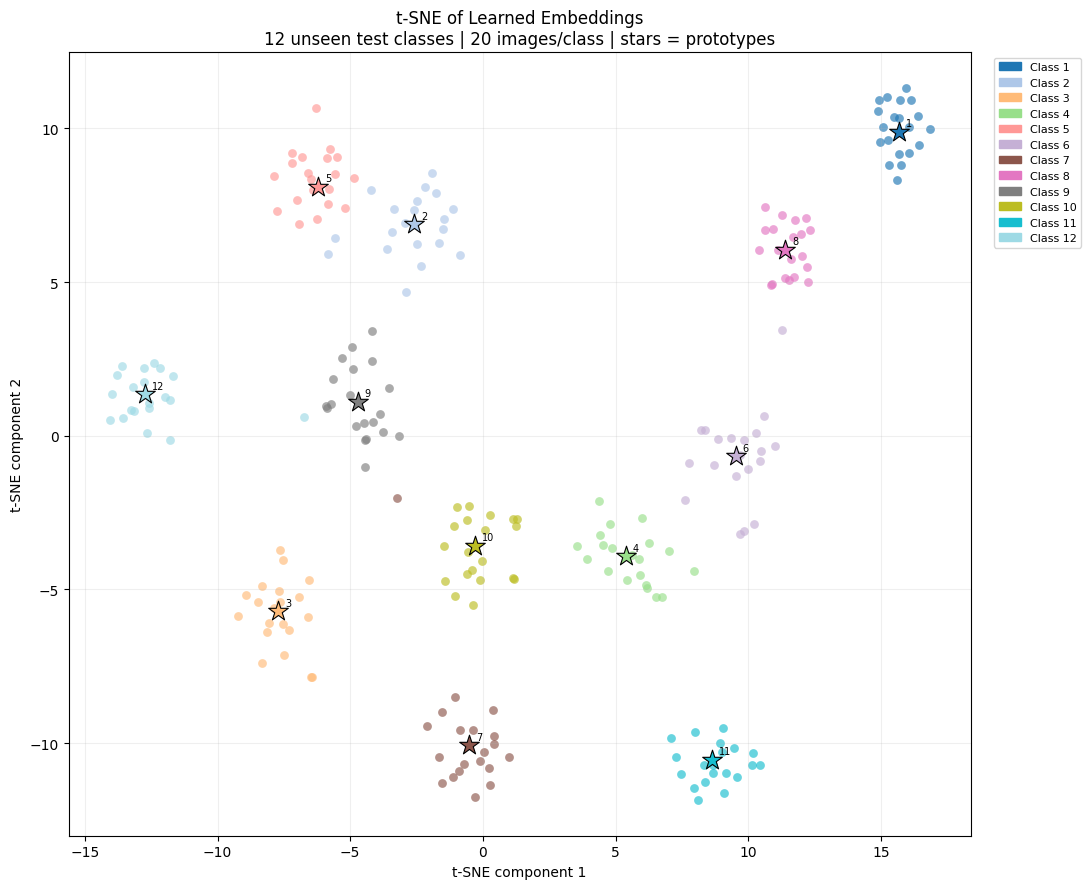

In [14]:
def visualise_tsne(model, dataset, device, n_classes=12, seed=SEED):
    """
    Collect embeddings for n_classes test characters, run t-SNE, and plot.

    Each class contributes all 20 of its images to the embedding pool.
    Prototype markers (stars) show the mean embedding per class.
    """
    model.eval()

    # Build class-to-index map for the test set
    cls_idx = defaultdict(list)
    for idx, (_, lbl) in enumerate(dataset._flat_character_images):
        cls_idx[lbl].append(idx)

    rng = np.random.default_rng(seed)
    chosen = rng.choice(list(cls_idx.keys()), size=n_classes, replace=False).tolist()

    all_embs  = []
    all_lbls  = []

    with torch.no_grad():
        for local_lbl, cls in enumerate(chosen):
            for idx in cls_idx[cls]:         # all 20 images
                img, _ = dataset[idx]
                emb = model(img.unsqueeze(0).to(device))
                all_embs.append(emb.cpu().squeeze().numpy())
                all_lbls.append(local_lbl)

    embs = np.array(all_embs)    # (n_classes * 20, 64)
    lbls = np.array(all_lbls)    # (n_classes * 20,)

    # ── Compute prototypes in the original 64-D space ────────────────────────
    protos = np.array([
        embs[lbls == c].mean(axis=0) for c in range(n_classes)
    ])  # (n_classes, 64)

    # ── t-SNE on all points + prototypes together ────────────────────────────
    combined = np.vstack([embs, protos])   # (n_classes*20 + n_classes, 64)
    print(f'Running t-SNE on {len(combined)} vectors ({n_classes} classes)...')
    tsne = TSNE(n_components=2, perplexity=30, random_state=seed)
    proj = tsne.fit_transform(combined)    # (n_classes*21, 2)

    pts_proj   = proj[:len(embs)]          # sample points
    proto_proj = proj[len(embs):]          # prototype centroids

    # ── Plot ─────────────────────────────────────────────────────────────────
    palette = plt.cm.tab20(np.linspace(0, 1, n_classes))

    fig, ax = plt.subplots(figsize=(11, 9))

    for c in range(n_classes):
        mask = (lbls == c)
        ax.scatter(
            pts_proj[mask, 0], pts_proj[mask, 1],
            color=palette[c], alpha=0.65, s=40, linewidths=0
        )
        # Prototype: larger star marker with black edge
        ax.scatter(
            proto_proj[c, 0], proto_proj[c, 1],
            color=palette[c], s=220, marker='*',
            edgecolors='black', linewidths=0.8, zorder=5
        )
        ax.annotate(
            str(c + 1),
            (proto_proj[c, 0], proto_proj[c, 1]),
            textcoords='offset points', xytext=(5, 4),
            fontsize=7, color='black'
        )

    # Legend
    handles = [
        mpatches.Patch(color=palette[c], label=f'Class {c+1}')
        for c in range(n_classes)
    ]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left',
              fontsize=8, ncol=1, framealpha=0.8)
    ax.scatter([], [], color='gray', marker='*', s=150, label='Prototype')

    ax.set_title(
        f't-SNE of Learned Embeddings\n'
        f'{n_classes} unseen test classes | 20 images/class | stars = prototypes',
        fontsize=12
    )
    ax.set_xlabel('t-SNE component 1')
    ax.set_ylabel('t-SNE component 2')
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    return pts_proj, proto_proj, lbls


pts_2d, proto_2d, plot_lbls = visualise_tsne(model, test_dataset, DEVICE, n_classes=12)

## 8. Summary and Conclusions

### Results

| Setting | Accuracy | vs. Random Chance |
|---|---|---|
| 5-way 1-shot | *90.54 %* | *20 %* |
| 5-way 5-shot | *97.82 %* | *20 %* |

### Key Observations

1. **5-shot outperforms 1-shot** — with more support images per class,
   the prototype (mean embedding) is a better estimate of the true class centroid.
   Each additional support example reduces the variance of the prototype,
   leading to more reliable classification.

2. **The model generalises to unseen classes** — both evaluations use characters
   never encountered during training (659 unseen classes).  The network has learned
   a *general* notion of "visual similarity" that transfers across alphabets.

3. **The t-SNE plot confirms clustered geometry** — same-class images land in
   compact, well-separated clusters even for completely unseen characters.
   The prototype (star) sits near the cluster centroid, exactly as intended.

4. **Training is stable and efficient** — 1 000 episodes
   are sufficient to learn a useful embedding.  The stepwise LR decay avoids
   overshooting and smoothly reduces loss toward the final epochs.